# Annual global mean $ET_0$

## Config and functions

In [ ]:
import scienceplots
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cmip6_archive as ca
from dask.distributed import Client, LocalCluster

In [2]:
# One worker per model keeps all 8 reads/reductions running concurrently.
cluster = LocalCluster(n_workers=8, threads_per_worker=1, memory_limit="25GiB")
client = cluster.get_client()
client

2026-08-26 15:13:08,449 [INFO]: proxy.py(<module>:86) >> To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-26 15:13:08,449 [INFO]: proxy.py(<module>:86) >> To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34717 instead
  warnings.warn(
2026-08-26 15:13:08,465 [INFO]: scheduler.py(__init__:1765) >> State start
2026-08-26 15:13:08,465 [INFO]: scheduler.py(__init__:1765) >> State start
2026-08-26 15:13:08,467 [INFO]: diskutils.py(_check_lock_or_purge:252) >> Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-wmxslk7m', purging
2026-08-26 15:13:08,467 [INFO]: diskutils.py(_check_lock_or_purge:252) >> Found 

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:34717/status,
Dashboard: http://127.0.0.1:34717/status,Workers: 8
Total threads: 8,Total memory: 200.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38055,Workers: 0
Dashboard: http://127.0.0.1:34717/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42319,Total threads: 1
Dashboard: http://127.0.0.1:37937/status,Memory: 25.00 GiB
Nanny: tcp://127.0.0.1:38013,


2026-08-26 15:13:53,026 [INFO]: scheduler.py(add_client:5953) >> Receive client connection: Client-worker-b18e36d9-a11d-11f1-bac1-b4e9b80bdade
2026-08-26 15:13:53,026 [INFO]: scheduler.py(add_client:5953) >> Receive client connection: Client-worker-b18e36d9-a11d-11f1-bac1-b4e9b80bdade
2026-08-26 15:13:53,027 [INFO]: core.py(handle_stream:883) >> Starting established connection to tcp://127.0.0.1:59180
2026-08-26 15:13:53,027 [INFO]: core.py(handle_stream:883) >> Starting established connection to tcp://127.0.0.1:59180
2026-08-26 15:13:53,027 [INFO]: scheduler.py(add_client:5953) >> Receive client connection: Client-worker-b18e393a-a11d-11f1-bacd-b4e9b80bdade
2026-08-26 15:13:53,027 [INFO]: scheduler.py(add_client:5953) >> Receive client connection: Client-worker-b18e393a-a11d-11f1-bacd-b4e9b80bdade
2026-08-26 15:13:53,028 [INFO]: core.py(handle_stream:883) >> Starting established connection to tcp://127.0.0.1:59194
2026-08-26 15:13:53,028 [INFO]: core.py(handle_stream:883) >> Starting 

In [ ]:
# Root folder where daily ET0 files are stored
BASEDIR = Path("/work10/archive/CMIP6/CMIP-SSPs/outputs")

# We plot the evolution of ET0 in the grid cell nearest to this (lat, lon)
#GRID_CELL = (37.178055, -3.600833)

def find_et0_file(model_dir: Path, model: str, expid: str) -> Path:
    """Find the ET0 (not ET0adv/ET0rad/VPD) file for a model/experiment.

    Uses a glob instead of a hardcoded date range because some models
    (e.g. UKESM1-0-LL, which runs a 360-day calendar) end their filenames
    in a different date than the rest (...1230 instead of ...1231).
    """
    matches = sorted(model_dir.glob(f"{model}_{expid}_daily_ET0_*.nc"))
    if not matches:
        raise FileNotFoundError(f"No ET0 file found in {model_dir} for {model}/{expid}")
    return matches[0]

def global_weighted_mean(da: xr.DataArray):
    "Calculates global spatial mean using cosine weighting."
    weights = np.cos(np.deg2rad(da.lat))   
    return da.weighted(weights).mean(("lon", "lat"))


def process_model(model: str, experiment: str, var: str, basedir: Path):
    """
    Calculates annual mean values at the specified grid cell.
    Runs entirely on one worker, start to finish, for a single model.
    """
    exp_dir = basedir / model / experiment
    path = find_et0_file(exp_dir, model, experiment)

    ds = xr.open_dataset(path, chunks={'time': 365*5, 'lon': -1, 'lat': -1})
    global_mean = global_weighted_mean(ds[var])
    annual = global_mean.groupby("time.year").mean("time").load()

    return annual["year"].values, annual.values

## Compute annual means

In [ ]:
from dask.distributed import progress

combinations = [(model, exp) for model in ca.MODELS for exp in ca.EXPERIMENTS]

all_futures = {model: {} for model in ca.MODELS}
for (model, exp) in combinations:
    future = client.submit(process_model, model, exp, 'ET0', BASEDIR)
    all_futures[model][exp] = future
    
progress(all_futures)

VBox()

In [ ]:
# Collect annual-mean series for every model x experiment combination
all_results = client.gather(all_futures, errors='raise')
all_results

{'IPSL-CM6A-LR': {'historical': (array([1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860,
          1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871,
          1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882,
          1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893,
          1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904,
          1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915,
          1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926,
          1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937,
          1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948,
          1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959,
          1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
          1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
          1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 

In [ ]:
# Save all results as .npy files
OUTDIR = Path("/work10/archive/CMIP6/CMIP-SSPs/code/daily-ET0/calculations/spatial_means")
for (model, exp) in combinations:
    years, values = all_results[model][exp]
    outpath = OUTDIR / f"{model}_{exp}_yearly_mean_ET0_{years[0]}-{years[-1]}.npy"
    np.save(file=outpath, arr=values )

## Load if already computed

In [ ]:
combinations = [(model, exp) for model in ca.MODELS for exp in ca.EXPERIMENTS]

# Load back all results from the.npy files
OUTDIR = Path("/work10/archive/CMIP6/CMIP-SSPs/code/daily-ET0/calculations/spatial_means")
all_results = {model: {} for model in ca.MODELS}
for (model, exp) in combinations:
    if exp == "historical":
        start_year, end_year = 1850, 2014
    else:
        start_year, end_year = 2015, 2100
    inpath = OUTDIR / f"{model}_{exp}_yearly_mean_ET0_{start_year}-{end_year}.npy"
    values = np.load(inpath)
    years = np.arange(start_year, end_year+1)
    all_results[model][exp] = years, values

print(f"✅ Loaded data from {len(combinations)} model x experiment combinations")

✅ Loaded data from 40 model x experiment combinations


## Plot

In [28]:
# Line styling for each experiment (color + linewidth), shared across all panels
EXPERIMENT_STYLE = {
    "historical": {"color": "black", "linewidth": 1, "zorder": 0},
    "ssp126": {"color": "#1965B0", "linewidth": 0.6, "zorder": 1},
    "ssp245": {"color": "#90C987", "linewidth": 0.6, "zorder": 2},
    "ssp370": {"color": "#F4A736", "linewidth": 0.6, "zorder": 3},
    "ssp585": {"color": "#DC050C", "linewidth": 0.6, "zorder": 4},
}

# Year at which the historical experiment ends and the SSPs begin
TRANSITION_YEAR = 2014

# Fixed x-axis range for the combined figure
XLIM = (1980, 2100)


	Saved figure to /work10/archive/CMIP6/CMIP-SSPs/code/daily-ET0/figures/annual_global_mean_all_experiments.png


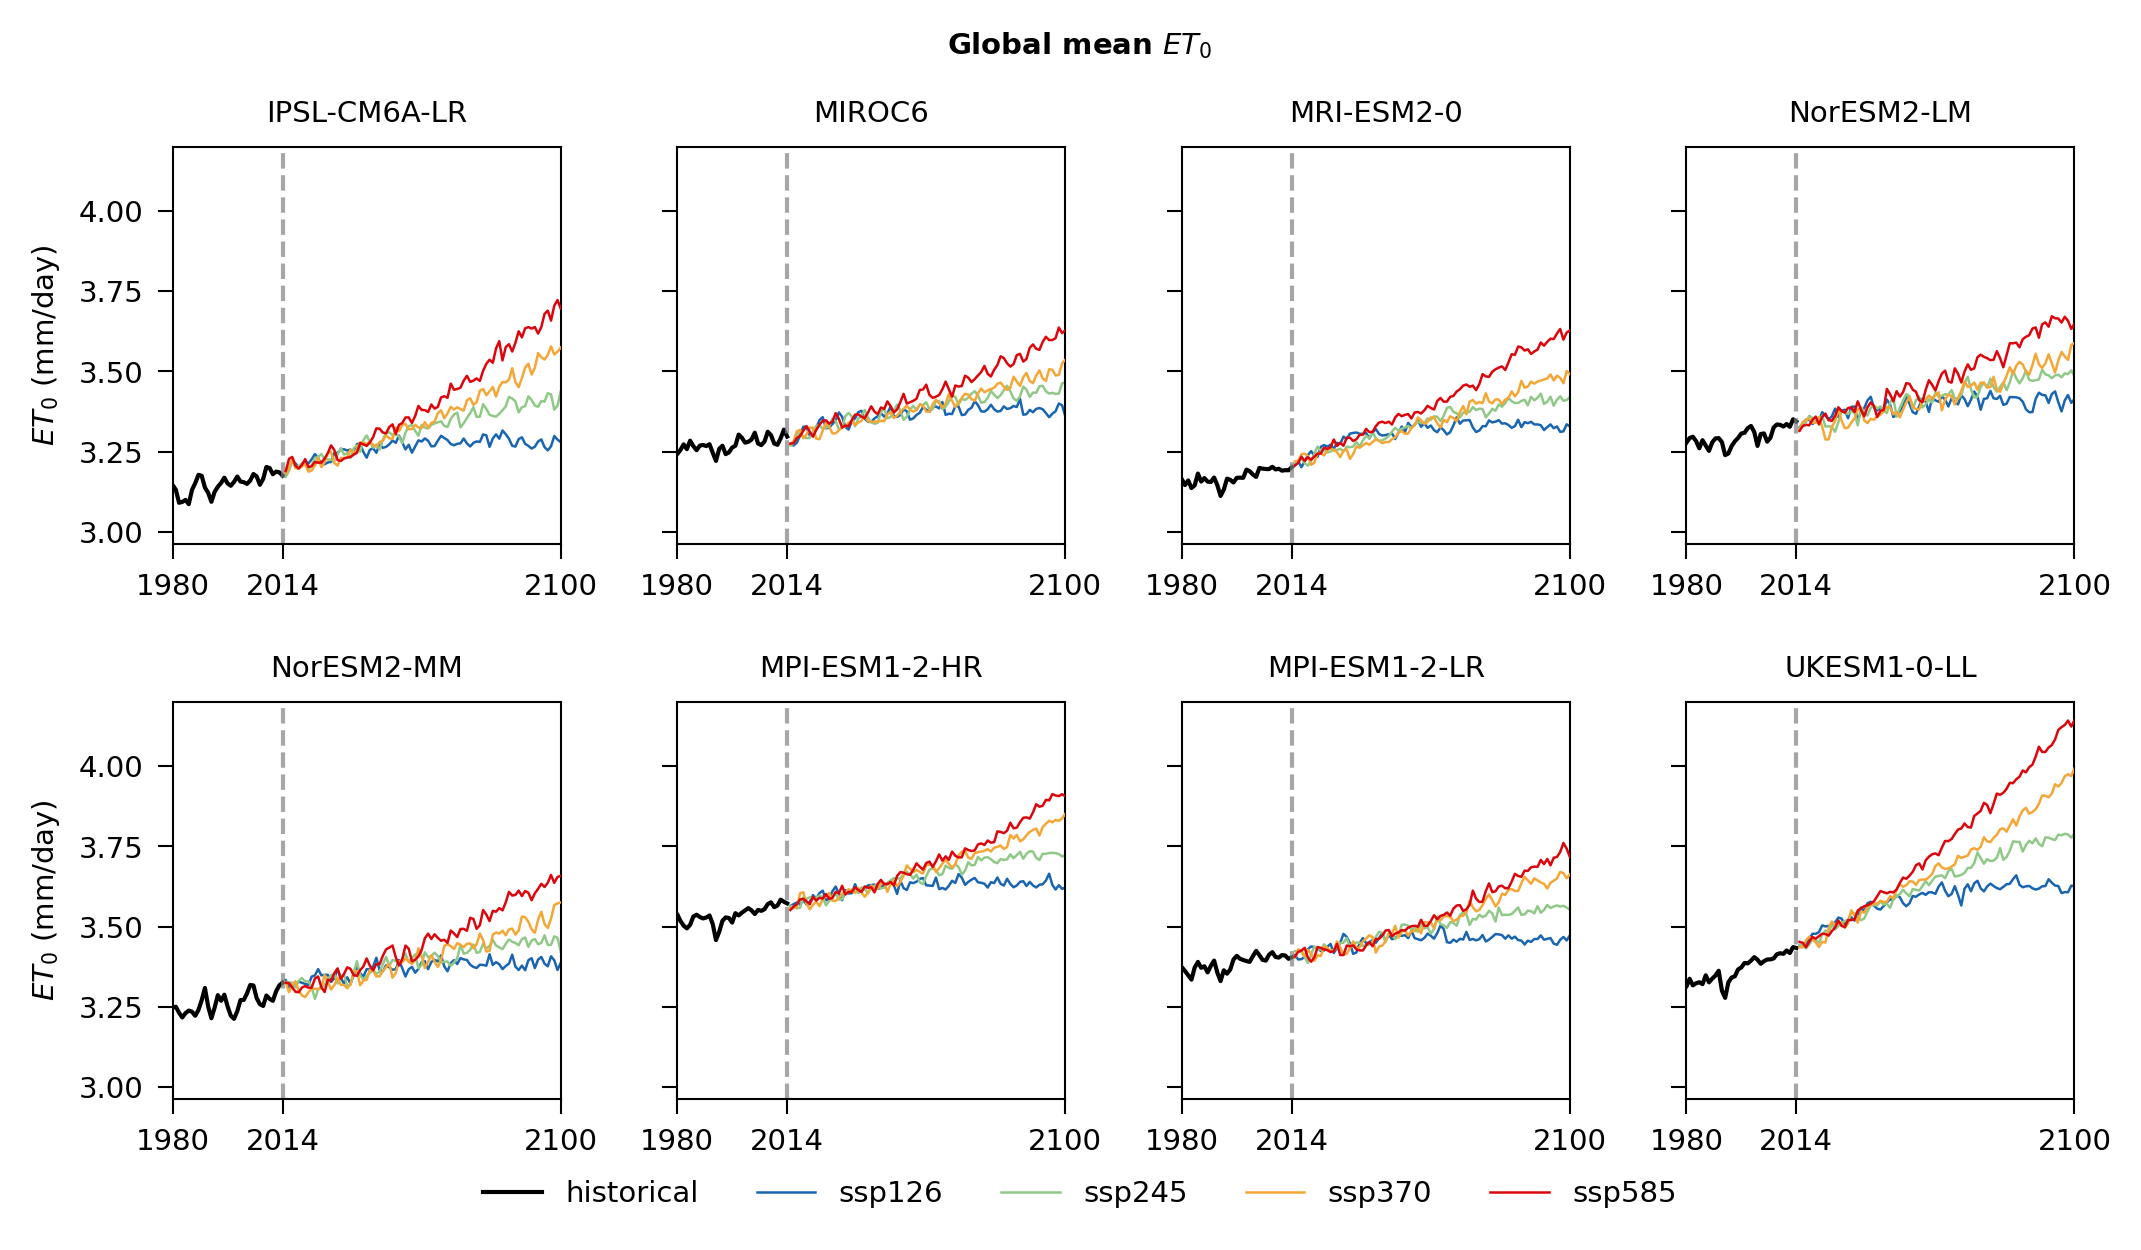

In [ ]:
from matplotlib import ticker

# Style adjustments (Nature style)
plt.style.use('nature')
mm = 1/25.4  # mm to inches
fig, axes = plt.subplots(2, 4, figsize=(180*mm, 100*mm), sharex=False, sharey=True)

plot_params = { "figure.dpi": "300",
               "font.size": 7,
               "axes.labelsize": 5,
               "figure.titlesize": 7,
               "xtick.major.width": 0.5,
               "ytick.major.width": 0.5,
               }
plt.rcParams.update(plot_params)

# One subplot for each model
for ax, model in zip(axes.flat, ca.MODELS):
    model_results = all_results[model]

    for experiment in ca.EXPERIMENTS:
        result = model_results.get(experiment)

        if isinstance(result, Exception) or result is None:
            ax.text(0.5, 0.5, "\tERROR\n" + experiment + str(result), ha="center", va="center",
                        transform=ax.transAxes, fontsize=7, color="red", wrap=True)
            continue

        years, values = result
        style = EXPERIMENT_STYLE[experiment]
        ax.plot(years, values, color=style["color"], linewidth=style["linewidth"],
                    zorder=style["zorder"])

    # Dashed grey vertical line marking the end of the historical experiment / start of the SSPs
    ax.axvline(TRANSITION_YEAR, color="grey", linestyle="--", linewidth=1, alpha=0.7)
    
    ax.set_title(model, size=7)
    ax.set_xlim(*XLIM)
    ax.xaxis.set_major_locator(ticker.FixedLocator([1980, 2014, 2100]))
   

for ax in axes[:, 0]:
    ax.set_ylabel(r"$ET_0$ (mm/day)")

# Shared legend for the whole figure
legend_handles = [
    Line2D([0], [0], color=style["color"], linewidth=style["linewidth"], label=experiment)
    for experiment, style in EXPERIMENT_STYLE.items()
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.04), frameon=False)

fig.suptitle(r"Global mean $ET_0$")
fig.tight_layout()
fig.subplots_adjust(wspace=0.3, hspace=0.4)

# Export to png
outdir = Path("figures")
outdir.mkdir(exist_ok=True)
outpath = outdir / f"annual_global_mean_all_experiments.png"
fig.savefig(outpath, dpi=300, bbox_inches="tight")
print(f"\n\tSaved figure to {outpath.resolve()}")